# 🌪️ Cyclone EDA
## Analysis of historical cyclone patterns

This notebook is part of the Disaster Prediction System MCA Project.

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import os

# 1. Correct Path
DATA_PATH = r'C:\Users\adity\OneDrive\Desktop\disaster\data'

# 2. Join path with filename
cyclone_file = os.path.join(DATA_PATH, 'cyclone.csv')

# 3. Read the data
df= pd.read_csv(cyclone_file)

# 4. Verify it worked
print("Data loaded successfully!")
display(df.head())

Data loaded successfully!


,marine_region,nearest_state,nearest_district,lat,lon,sea_surface_temp,wind_speed,pressure,humidity,vorticity,month,year,cyclone_intensity,cyclone_risk
0,Bay of Bengal,Tamil Nadu,Nagapattinam,8.5,85.2,28.5,45,1002,75,0.8,5,2023,2,1
1,Bay of Bengal,Andaman and Nicobar Islands,Arong,12.3,92.1,29.1,120,985,88,1.5,10,2022,4,1
2,Bay of Bengal,Orissa,Puri District,15.7,88.4,30.2,85,995,82,1.2,6,2023,3,1
3,Bay of Bengal,Andaman and Nicobar Islands,Arong,10.2,90.5,28.8,38,1005,70,0.6,11,2021,1,0
4,Bay of Bengal,Mizoram,Saiha,18.9,93.2,30.5,155,978,92,2.1,5,2023,4,1


### Analysis of Cyclone Intensity & Risk

Cyclone Model Accuracy - Random Forest: 0.89
Cyclone Model Accuracy - Logistic Regression: 0.95


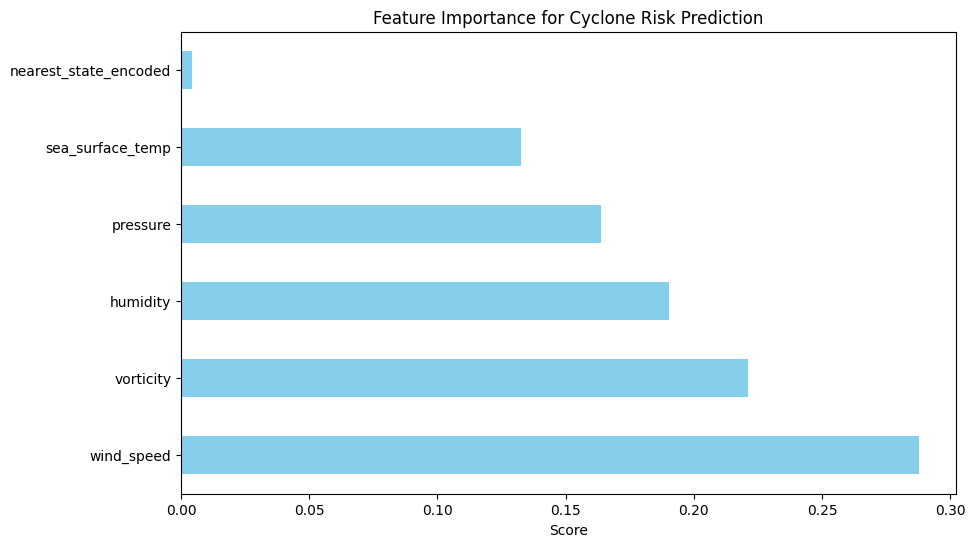

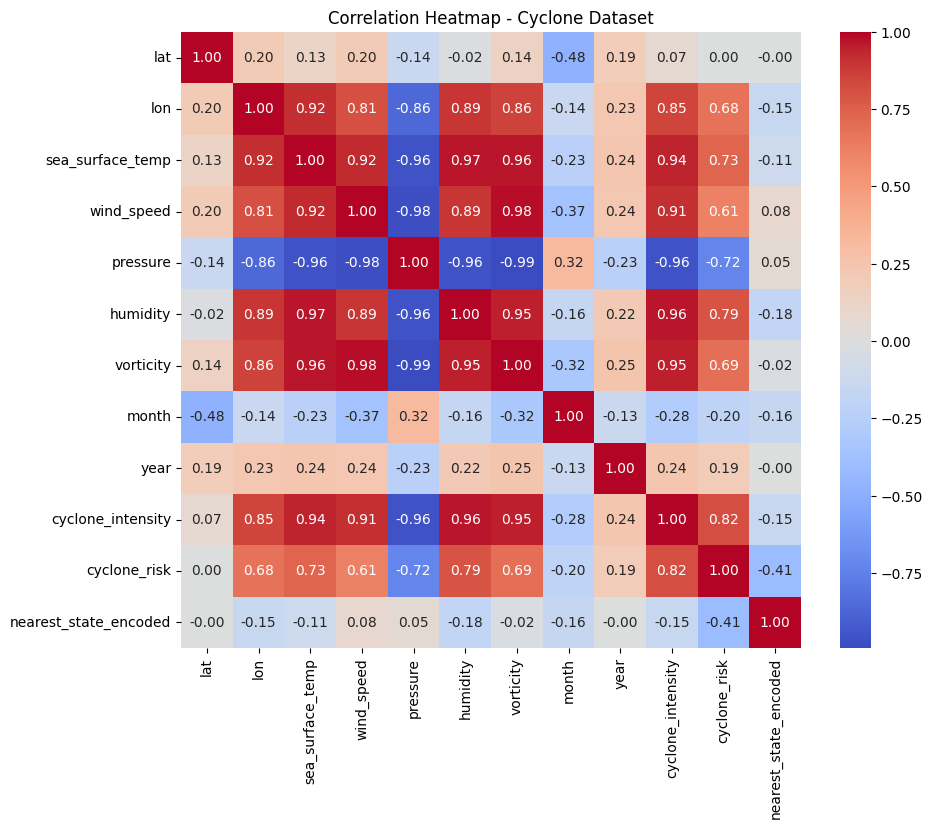

In [5]:
# Preprocessing
# Target: cyclone_risk (0 or 1) or cyclone_intensity
# Let's predict cyclone_risk
le = LabelEncoder()
df['nearest_state_encoded'] = le.fit_transform(df['nearest_state'])

X_cyc = df[['sea_surface_temp', 'wind_speed', 'pressure', 'humidity', 'vorticity', 'nearest_state_encoded']]
y_cyc = df['cyclone_risk']

X_train, X_test, y_train, y_test = train_test_split(X_cyc, y_cyc, test_size=0.2, random_state=42)

# Model 1: Random Forest
rf_cyc = RandomForestClassifier(n_estimators=100, random_state=42)
rf_cyc.fit(X_train, y_train)
y_pred_rf = rf_cyc.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

# Model 2: Logistic Regression
lr_cyc = LogisticRegression(max_iter=1000)
lr_cyc.fit(X_train, y_train)
y_pred_lr = lr_cyc.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

# Visualization 1: Feature Importance
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(rf_cyc.feature_importances_, index=X_cyc.columns)
feat_importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title('Feature Importance for Cyclone Risk Prediction')
plt.xlabel('Score')
plt.savefig('cyclone_feature_importance.png')

# Visualization 2: Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Cyclone Dataset')
plt.savefig('cyclone_correlation.png')

print(f"Cyclone Model Accuracy - Random Forest: {acc_rf:.2f}")
print(f"Cyclone Model Accuracy - Logistic Regression: {acc_lr:.2f}")

Visualization: Risk Correlation

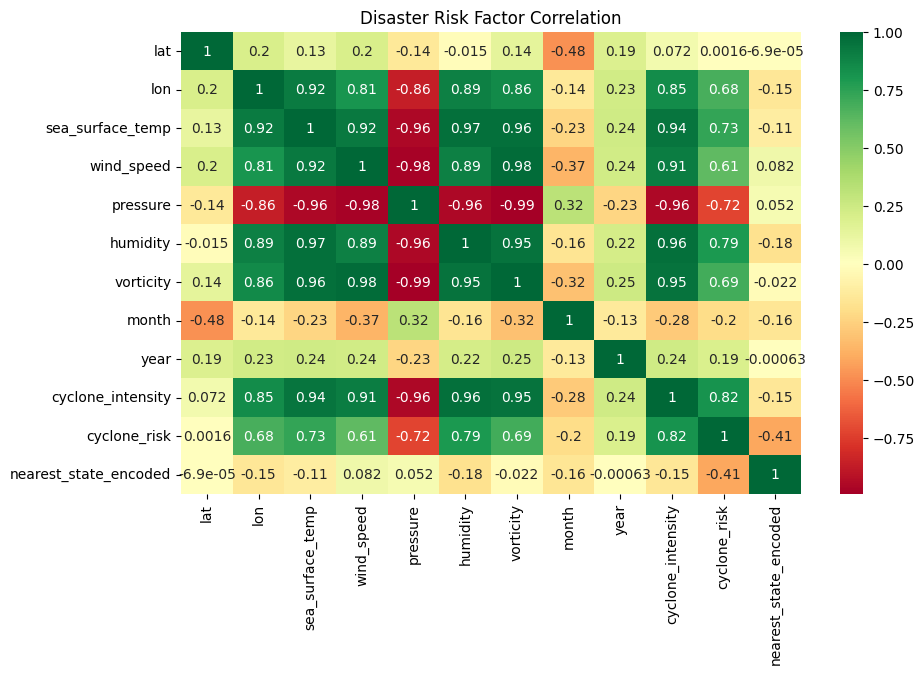

Random Forest Accuracy: 94.74%
Logistic Regression Accuracy: 94.74%


In [6]:
# 2. Visualization: Risk Correlation
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='RdYlGn')
plt.title('Disaster Risk Factor Correlation')
plt.show()

# 3. Prediction Model
X = df[['sea_surface_temp', 'wind_speed', 'pressure', 'humidity', 'vorticity']]
y = df['cyclone_risk']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Comparing Models
rf = RandomForestClassifier().fit(X_train, y_train)
lr = LogisticRegression().fit(X_train, y_train)

print(f"Random Forest Accuracy: {accuracy_score(y_test, rf.predict(X_test)):.2%}")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr.predict(X_test)):.2%}")